In [1]:
from google.cloud import bigquery


In [2]:
client = bigquery.Client(project="bi-project-2026")

C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\google\auth\_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


# Fill Rate


In [30]:
query = """
SELECT 
    c.city,
    o.product_id,
    p.product_name,
    p.category,
    CAST(SUM(o.actual_revenue) AS NUMERIC) as actual_revenue,
    CAST(SUM(o.expected_revenue) AS NUMERIC) as expected_revenue,
    ROUND(CAST(SUM(GREATEST(o.expected_revenue - o.actual_revenue, 0)) AS NUMERIC), 0) AS lost_revenue,
    ROUND(CAST(SUM(GREATEST(o.expected_revenue - o.expense, 0)) AS NUMERIC), 0) AS expected_profit,
    ROUND(AVG(SAFE_DIVIDE(o.delivered_qty, o.order_qty)) * 100, 2) AS avg_fill_rate,
    ROUND(COUNTIF(o.actual_delivery_date > o.agreed_delivery_date) / COUNT(o.order_id) * 100, 2) AS avg_late_pct
FROM analytics.dim_customers c
JOIN analytics.fact_order_lines o ON c.customer_id = o.customer_id
JOIN analytics.dim_products p ON p.product_id = o.product_id
GROUP BY c.city, o.product_id, p.product_name, p.category
"""
performance = client.query(query).to_dataframe()
performance

C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,city,product_id,product_name,category,actual_revenue,expected_revenue,lost_revenue,expected_profit,avg_fill_rate,avg_late_pct
0,Ahmedabad,25891202,AM Butter 250,Dairy,20202468000.000000000,20957574000.000000000,755106000.000000000,5346576000.000000000,96.34,27.59
1,Ahmedabad,25891203,AM Butter 500,Dairy,20855934000.000000000,21544314000.000000000,688380000.000000000,3532371000.000000000,96.81,30.31
2,Ahmedabad,25891302,AM Ghee 150,Dairy,8681279000.000000000,8967061000.000000000,285782000.000000000,1933324000.000000000,96.97,32.40
3,Ahmedabad,25891402,AM Curd 100,Dairy,20057596000.000000000,20700212000.000000000,642616000.000000000,5657015000.000000000,97.01,29.29
4,Ahmedabad,25891403,AM Curd 50,Dairy,53055093000.000000000,54767643000.000000000,1712550000.000000000,12179201000.000000000,96.88,32.34
5,Ahmedabad,25891601,AM Tea 500,Beverages,2275433000.000000000,2348975000.000000000,73542000.000000000,876636000.000000000,96.91,29.91
6,Ahmedabad,25891603,AM Tea 100,Beverages,4118319000.000000000,4257912000.000000000,139593000.000000000,1733781000.000000000,96.73,30.23
7,Ahmedabad,25891501,AM Biscuits 750,Food,16257951000.000000000,16752198000.000000000,494247000.000000000,2923596000.000000000,97.03,29.32
8,Ahmedabad,25891503,AM Biscuits 250,Food,6511540000.000000000,6735680000.000000000,224140000.000000000,1526448000.000000000,96.69,30.50
9,Ahmedabad,25891303,AM Ghee 100,Dairy,7084660000.000000000,7315440000.000000000,230780000.000000000,1583306000.000000000,96.67,29.75


- tổng lost revenue/profit (chiếm %)
- lost revenue/profit theo thời gian (tháng)
- lost revenue/profit theo thành phố/category

In [ ]:
import pandas as pd

summary = performance[['expected_revenue', 'actual_revenue', 'lost_revenue', 'expected_profit']].sum().to_frame().T


summary

,expected_revenue,actual_revenue,lost_revenue,expected_profit
0,1211029619000.000000000,1169939772000.000000000,41089847000.000000000,277706384000.000000000


In [50]:
expense = summary['expected_revenue'] - summary['expected_profit']
actual_profit = summary['actual_revenue'] - expense
summary['expense'] = expense
summary['actual_profit'] = actual_profit
summary['lost_profit'] = summary['expected_profit'] - actual_profit
summary

,expected_revenue,actual_revenue,lost_revenue,expected_profit,expense,actual_profit,lost_profit
0,1211029619000.000000000,1169939772000.000000000,41089847000.000000000,277706384000.000000000,933323235000.000000000,236616537000.000000000,41089847000.000000000


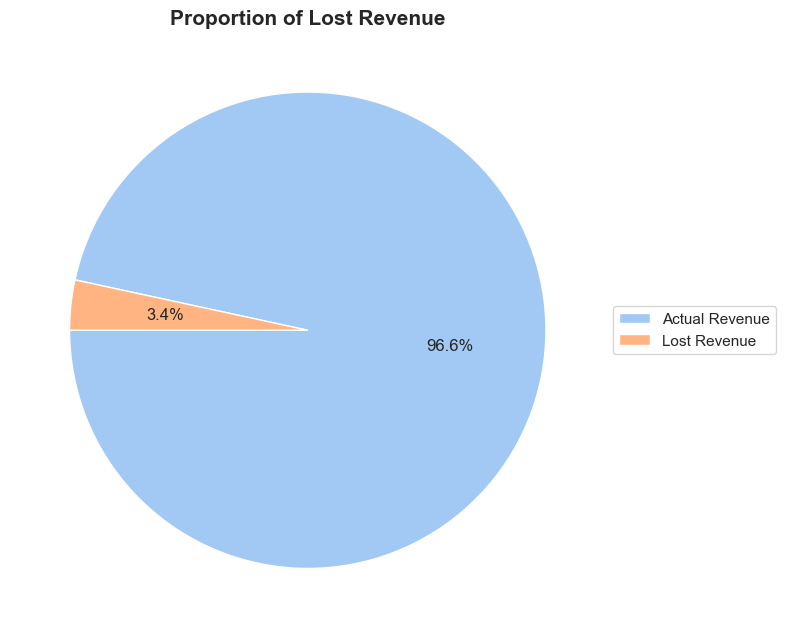

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['Actual Revenue', 'Lost Revenue']
values = [summary['actual_revenue'].iloc[0], summary['lost_revenue'].iloc[0]]

colors = sns.color_palette('pastel')[0:2]

plt.figure(figsize=(8, 8))

plt.pie(
    values, 
    autopct='%1.1f%%', 
    startangle=180, 
    colors=colors,
)

plt.legend(
    labels=['Actual Revenue', 'Lost Revenue'], 
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title('Proportion of Lost Revenue', fontweight='bold', fontsize=15)

plt.tight_layout()
plt.show()

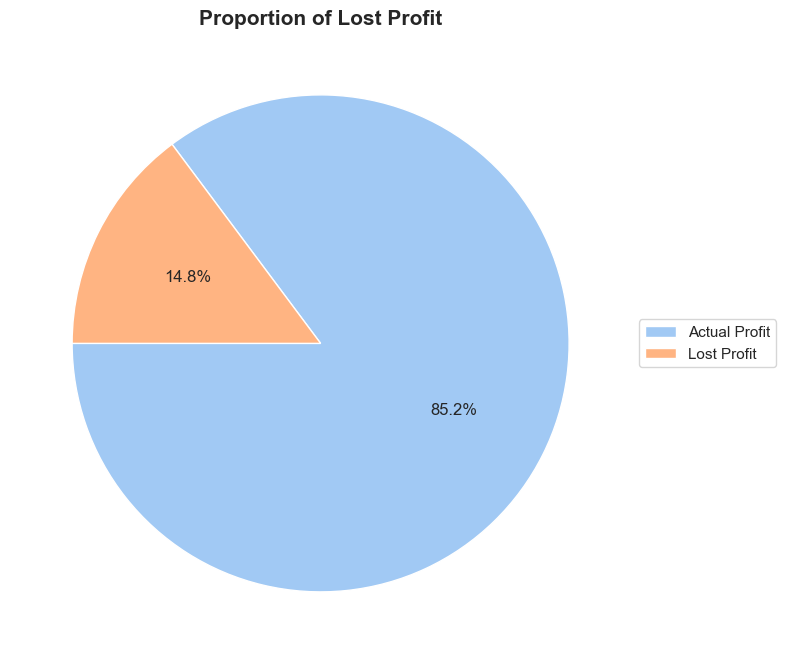

In [61]:
labels = ['Actual Profit', 'Lost Profit']
values = [summary['actual_profit'].iloc[0], summary['lost_profit'].iloc[0]]

colors = sns.color_palette('pastel')[0:2]

plt.figure(figsize=(8, 8))

plt.pie(
    values, 
    autopct='%1.1f%%', 
    startangle=180, 
    colors=colors,
)

plt.legend(
    labels=['Actual Profit', 'Lost Profit'], 
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title('Proportion of Lost Profit', fontweight='bold', fontsize=15)

plt.tight_layout()
plt.show()

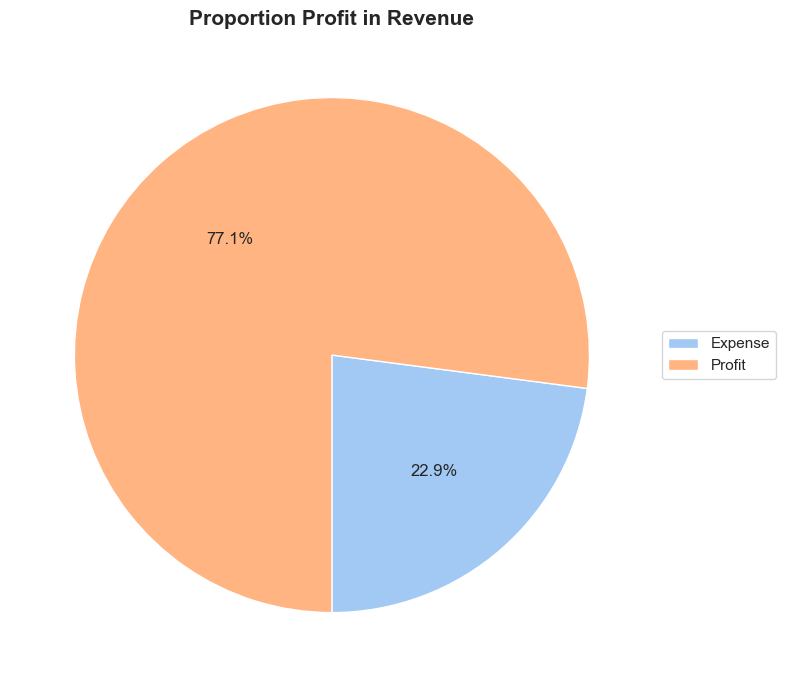

In [68]:
labels = ['Expense', 'Profit']
values = [summary['expected_profit'].iloc[0], summary['expense'].iloc[0]]

colors = sns.color_palette('pastel')[0:2]

plt.figure(figsize=(8, 8))

plt.pie(
    values, 
    autopct='%1.1f%%', 
    startangle=270, 
    colors=colors,
)

plt.legend(
    labels=labels, 
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title('Proportion Profit in Revenue', fontweight='bold', fontsize=15)

plt.tight_layout()
plt.show()

lost revenue theo tháng

In [ ]:
query = """
SELECT 
    DATE_TRUNC(o.order_placement_date, MONTH) as order_month,
    CAST(SUM(o.actual_revenue) AS NUMERIC) as actual_revenue,
    CAST(SUM(o.expected_revenue) AS NUMERIC) as expected_revenue,
    ROUND(CAST(SUM(GREATEST(o.expected_revenue - o.actual_revenue, 0)) AS NUMERIC), 0) AS lost_revenue
FROM analytics.fact_order_lines o
GROUP BY order_month
ORDER BY order_month ASC
"""
lost_rev_month = client.query(query).to_dataframe()
lost_rev_month

C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_month,total_orders,actual_revenue,expected_revenue,lost_revenue
0,2022-03-01,9754,198587076000.000000000,205478280000.000000000,6891204000.000000000
1,2022-04-01,9403,191554622000.000000000,198332553000.000000000,6777931000.000000000
2,2022-05-01,9756,199786915000.000000000,206796312000.000000000,7009397000.000000000
3,2022-06-01,9389,191160342000.000000000,198042667000.000000000,6882325000.000000000
4,2022-07-01,9685,198830255000.000000000,205809452000.000000000,6979197000.000000000
5,2022-08-01,9109,190020562000.000000000,196570355000.000000000,6549793000.000000000


In [104]:

lost_rev_month['expected_revenue'] = lost_rev_month['expected_revenue'].astype(float)
lost_rev_month['lost_revenue'] = lost_rev_month['lost_revenue'].astype(float)

lost_rev_month['lost_rev_pct'] = (lost_rev_month['lost_revenue'] / lost_rev_month['expected_revenue']) * 100

lost_rev_month['lost_rev_pct'] = lost_rev_month['lost_rev_pct'].round(2)

lost_rev_month

,order_month,total_orders,actual_revenue,expected_revenue,lost_revenue,lost_rev_pct
0,2022-03-01,9754,198587076000.000000000,2.054783e+11,6.891204e+09,3.35
1,2022-04-01,9403,191554622000.000000000,1.983326e+11,6.777931e+09,3.42
2,2022-05-01,9756,199786915000.000000000,2.067963e+11,7.009397e+09,3.39
3,2022-06-01,9389,191160342000.000000000,1.980427e+11,6.882325e+09,3.48
4,2022-07-01,9685,198830255000.000000000,2.058095e+11,6.979197e+09,3.39
5,2022-08-01,9109,190020562000.000000000,1.965704e+11,6.549793e+09,3.33


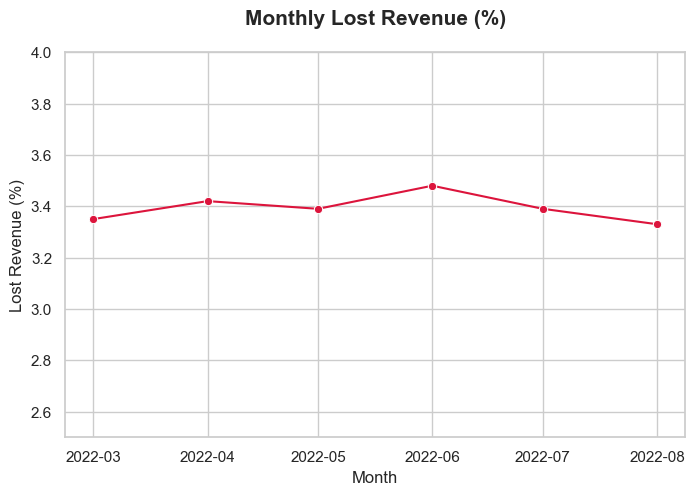

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker 

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Vẽ biểu đồ
ax = sns.lineplot(data=lost_rev_month, x='order_month', y='lost_rev_pct', marker='o', color='Crimson')
ax.set_ylim(2.5, 4)



plt.title('Monthly Lost Revenue (%)', fontweight='bold', fontsize=15, pad=20)
plt.ylabel('Lost Revenue (%)', fontsize=12)
plt.xlabel('Month', fontsize=12)

plt.show()

In [114]:
query = """
WITH base_metrics AS (
    SELECT 
        DATE_TRUNC(o.order_placement_date, MONTH) as order_month,
        CAST(SUM(o.actual_revenue) AS NUMERIC) as actual_revenue,
        CAST(SUM(o.expected_revenue) AS NUMERIC) as expected_revenue,
        CAST(SUM(o.expense) AS NUMERIC) as total_expense
    FROM analytics.fact_order_lines o
    GROUP BY order_month
)
SELECT 
    order_month,
    actual_revenue,
    expected_revenue,
    total_expense,
    -- Tính Lost Revenue
    ROUND(CAST(expected_revenue - actual_revenue AS NUMERIC), 0) AS lost_revenue,
    -- Tính Expected Profit = Expected Revenue - Expense
    ROUND(CAST(expected_revenue - total_expense AS NUMERIC), 0) AS expected_profit,
    -- Tính Actual Profit = Actual Revenue - Expense
    ROUND(CAST(actual_revenue - total_expense AS NUMERIC), 0) AS actual_profit,
    -- Tính Lost Profit = Expected Profit - Actual Profit (Nó chính bằng Lost Revenue)
    ROUND(CAST((expected_revenue - total_expense) - (actual_revenue - total_expense) AS NUMERIC), 0) AS lost_profit
FROM base_metrics
ORDER BY order_month ASC
"""
lost_pro_month = client.query(query).to_dataframe()
lost_pro_month

C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_month,actual_revenue,expected_revenue,total_expense,lost_revenue,expected_profit,actual_profit,lost_profit
0,2022-03-01,198587076000.000000000,205478280000.000000000,158308235000.000000000,6891204000.000000000,47170045000.000000000,40278841000.000000000,6891204000.000000000
1,2022-04-01,191554622000.000000000,198332553000.000000000,152845517000.000000000,6777931000.000000000,45487036000.000000000,38709105000.000000000,6777931000.000000000
2,2022-05-01,199786915000.000000000,206796312000.000000000,159275062000.000000000,7009397000.000000000,47521250000.000000000,40511853000.000000000,7009397000.000000000
3,2022-06-01,191160342000.000000000,198042667000.000000000,152617982000.000000000,6882325000.000000000,45424685000.000000000,38542360000.000000000,6882325000.000000000
4,2022-07-01,198830255000.000000000,205809452000.000000000,158657358000.000000000,6979197000.000000000,47152094000.000000000,40172897000.000000000,6979197000.000000000
5,2022-08-01,190020562000.000000000,196570355000.000000000,151619081000.000000000,6549793000.000000000,44951274000.000000000,38401481000.000000000,6549793000.000000000


In [115]:

lost_pro_month['expected_profit'] = lost_pro_month['expected_profit'].astype(float)
lost_pro_month['lost_profit'] = lost_pro_month['lost_profit'].astype(float)

lost_pro_month['lost_pro_pct'] = (lost_pro_month['lost_profit'] / lost_pro_month['expected_profit']) * 100

lost_pro_month['lost_pro_pct'] = lost_pro_month['lost_pro_pct'].round(2)

lost_pro_month

,order_month,actual_revenue,expected_revenue,total_expense,lost_revenue,expected_profit,actual_profit,lost_profit,lost_pro_pct
0,2022-03-01,198587076000.000000000,205478280000.000000000,158308235000.000000000,6891204000.000000000,4.717004e+10,40278841000.000000000,6.891204e+09,14.61
1,2022-04-01,191554622000.000000000,198332553000.000000000,152845517000.000000000,6777931000.000000000,4.548704e+10,38709105000.000000000,6.777931e+09,14.90
2,2022-05-01,199786915000.000000000,206796312000.000000000,159275062000.000000000,7009397000.000000000,4.752125e+10,40511853000.000000000,7.009397e+09,14.75
3,2022-06-01,191160342000.000000000,198042667000.000000000,152617982000.000000000,6882325000.000000000,4.542468e+10,38542360000.000000000,6.882325e+09,15.15
4,2022-07-01,198830255000.000000000,205809452000.000000000,158657358000.000000000,6979197000.000000000,4.715209e+10,40172897000.000000000,6.979197e+09,14.80
5,2022-08-01,190020562000.000000000,196570355000.000000000,151619081000.000000000,6549793000.000000000,4.495127e+10,38401481000.000000000,6.549793e+09,14.57


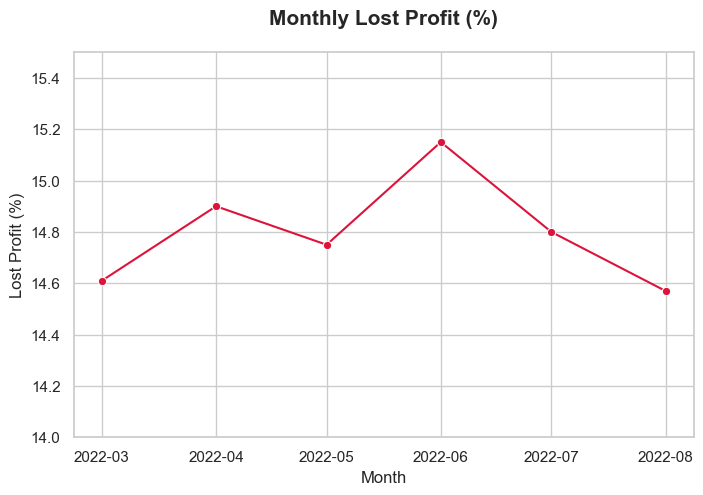

In [120]:

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Vẽ biểu đồ
ax = sns.lineplot(data=lost_pro_month, x='order_month', y='lost_pro_pct', marker='o', color='Crimson')
ax.set_ylim(14, 15.5)



plt.title('Monthly Lost Profit (%)', fontweight='bold', fontsize=15, pad=20)
plt.ylabel('Lost Profit (%)', fontsize=12)
plt.xlabel('Month', fontsize=12)

plt.show()

In [122]:
query = """
SELECT 
    DATE_TRUNC(o.order_placement_date, MONTH) as order_month,
    COUNT(order_id) as total_orders
FROM analytics.fact_order_lines o
GROUP BY order_month
ORDER BY order_month ASC
"""
lost_count_month = client.query(query).to_dataframe()
lost_count_month

C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_month,total_orders
0,2022-03-01,9754
1,2022-04-01,9403
2,2022-05-01,9756
3,2022-06-01,9389
4,2022-07-01,9685
5,2022-08-01,9109


# Late Percentage

In [126]:
query = """
SELECT
    ROUND(AVG(o.on_time), 2) AS avg_on_time_rate,
    ROUND(AVG(o.in_full), 2) AS avg_infull_rate,
    ROUND(AVG(SAFE_DIVIDE(o.delivered_qty, o.order_qty)) * 100, 2) AS avg_fill_rate,
    ROUND(COUNTIF(o.actual_delivery_date > o.agreed_delivery_date) / COUNT(o.order_id) * 100, 2) AS avg_late_pct
FROM analytics.fact_order_lines o
"""
late_pct_overall = client.query(query).to_dataframe()
late_pct_overall

C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,avg_on_time_rate,avg_infull_rate,avg_fill_rate,avg_late_pct
0,0.71,0.66,96.59,28.88


In [132]:
query = """
SELECT
    DATE_TRUNC(o.order_placement_date, MONTH) as order_month,
    ROUND(COUNTIF(o.actual_delivery_date > o.agreed_delivery_date) / COUNT(o.order_id) * 100, 2) AS avg_late_pct
FROM analytics.fact_order_lines o
GROUP BY order_month
ORDER BY order_month ASC

"""
late_pct_month = client.query(query).to_dataframe()
late_pct_month

C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_month,avg_late_pct
0,2022-03-01,28.54
1,2022-04-01,28.62
2,2022-05-01,29.46
3,2022-06-01,29.11
4,2022-07-01,28.20
5,2022-08-01,29.40


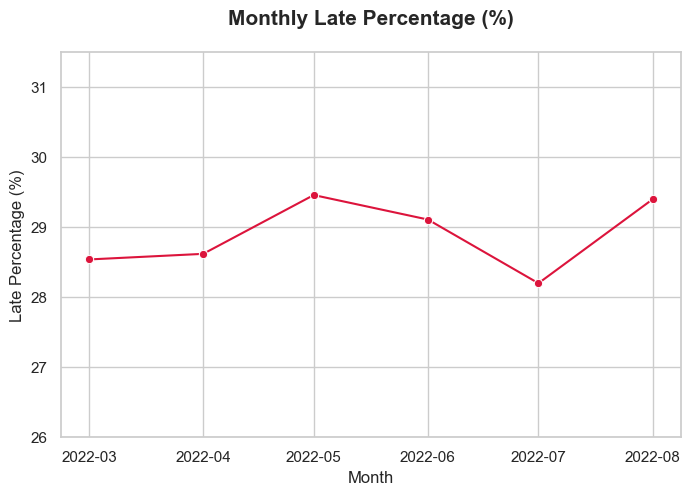

In [138]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Vẽ biểu đồ
ax = sns.lineplot(data=late_pct_month, x='order_month', y='avg_late_pct', marker='o', color='Crimson')
ax.set_ylim(26, 31.5)



plt.title('Monthly Late Percentage (%)', fontweight='bold', fontsize=15, pad=20)
plt.ylabel('Late Percentage (%)', fontsize=12)
plt.xlabel('Month', fontsize=12)

plt.show()